In [ ]:
# Cell 2: Connect to Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# Create a main project folder
project_path = '/content/drive/My Drive/Infant_App_Project/Posture_Analysis'
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Created project folder at: {project_path}")
else:
    print(f"Project folder already exists: {project_path}")

Mounted at /content/drive
Project folder already exists: /content/drive/My Drive/Infant_App_Project/Posture_Analysis


Dataset Confirmation & Setup
We will use the Roboflow "Baby Posture" Dataset you identified earlier.

Goal: To confirm we have clear, full-body images of babies (not just faces).

Why: Model 2 needs to see shoulders, hips, and knees to calculate symmetry.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="i8WNUd3E7pd2fVmEMlef")
project = rf.workspace("theekshana").project("baby_posture-1pqtl")
version = project.version(1)
dataset = version.download("yolov5")

print("✅ If you see this, the dataset is finally downloaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 55.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to baby_posture-1 in yolov5pytorch:: 100%|██████████| 8630/8630 [00:01<00:00, 5484.80it/s]


✅ If you see this, the dataset is finally downloaded!


verifying and cleaning the dataset

In [ ]:
# Cell 2: Sanity Check & Cleaning
# ---------------------------------------------------------
import os
import cv2
import hashlib
import glob

# Paths: Roboflow usually downloads to a folder named after the project
# This script finds that folder automatically
base_dirs = [d for d in os.listdir('.') if os.path.isdir(d) and not d.startswith('.') and 'drive' not in d]
if base_dirs:
    dataset_path = os.path.abspath(base_dirs[0])
    print(f"📂 Found dataset at: {dataset_path}")
else:
    print("❌ Could not find dataset folder. Please check the file browser on the left.")
    dataset_path = ""

if dataset_path:
    image_files = glob.glob(f"{dataset_path}/**/*.jpg", recursive=True) + \
                  glob.glob(f"{dataset_path}/**/*.jpeg", recursive=True) + \
                  glob.glob(f"{dataset_path}/**/*.png", recursive=True)

    print(f"🧐 Inspecting {len(image_files)} raw images...")

    bad_files = 0
    duplicates = 0
    hashes = set()

    for img_path in image_files:
        try:
            # TEST 1: Can OpenCV open it?
            img = cv2.imread(img_path)
            if img is None:
                os.remove(img_path)
                bad_files += 1
                continue

            # TEST 2: Is it a Duplicate? (Check MD5 Hash)
            file_hash = hashlib.md5(open(img_path, 'rb').read()).hexdigest()
            if file_hash in hashes:
                os.remove(img_path)
                duplicates += 1
                continue
            else:
                hashes.add(file_hash)

        except Exception:
            os.remove(img_path)
            bad_files += 1

    print("-" * 30)
    print(f"✅ Cleaning Complete!")
    print(f"🗑️ Removed {bad_files} corrupt files.")
    print(f"🗑️ Removed {duplicates} duplicate files.")
    print(f"✨ Total Valid Images Remaining: {len(hashes)}")

📂 Found dataset at: /content/baby_posture-1
🧐 Inspecting 4309 raw images...
------------------------------
✅ Cleaning Complete!
🗑️ Removed 0 corrupt files.
🗑️ Removed 35 duplicate files.
✨ Total Valid Images Remaining: 4274


Visual Audit - confirm they are full-body images of babies.

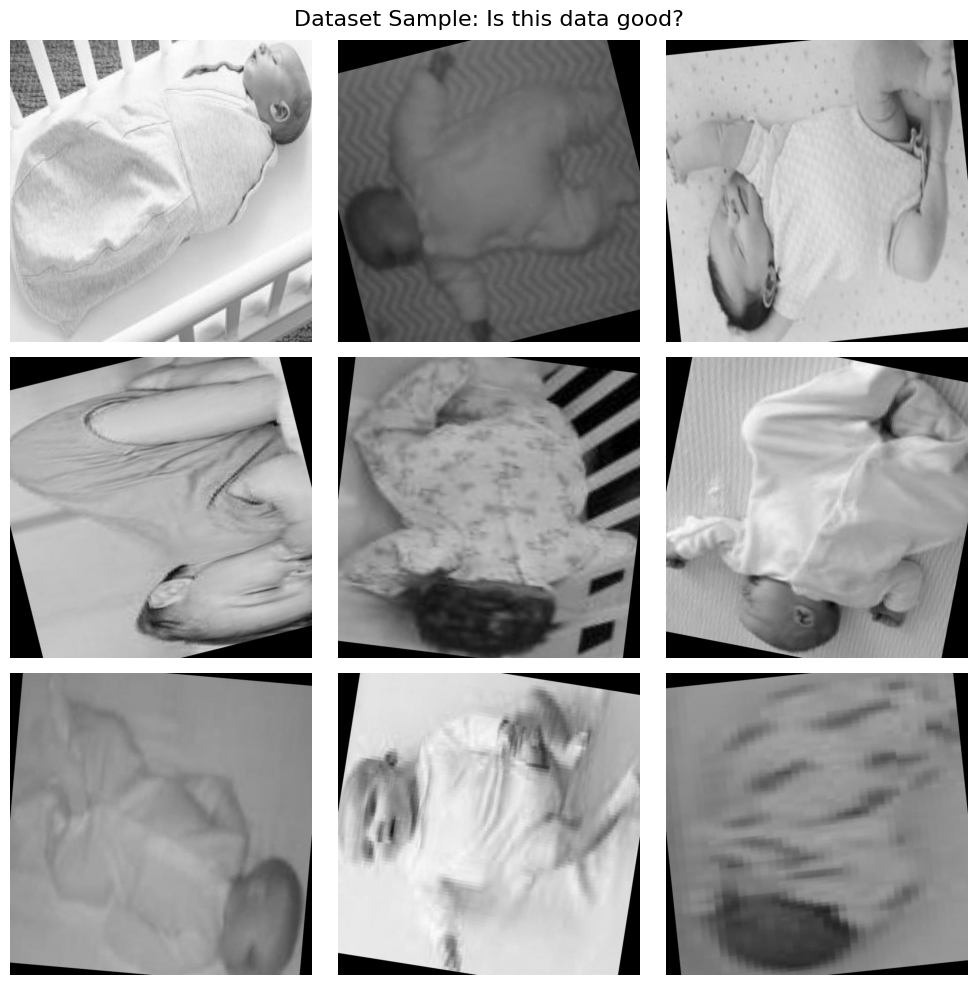

👀 LOOK ABOVE: Do you see full bodies (shoulders + hips)?


In [ ]:
# Cell 3: Visual Audit
# ---------------------------------------------------------
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Find valid images again after cleaning
if dataset_path:
    valid_images = glob.glob(f"{dataset_path}/**/*.jpg", recursive=True) + \
                   glob.glob(f"{dataset_path}/**/*.jpeg", recursive=True) + \
                   glob.glob(f"{dataset_path}/**/*.png", recursive=True)

    if len(valid_images) > 0:
        # Pick 9 random images
        samples = random.sample(valid_images, min(9, len(valid_images)))

        plt.figure(figsize=(10, 10))
        plt.suptitle("Dataset Sample: Is this data good?", fontsize=16)

        for i, img_path in enumerate(samples):
            img = mpimg.imread(img_path)
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.axis('off')

        plt.tight_layout()
        plt.show()

        print("👀 LOOK ABOVE: Do you see full bodies (shoulders + hips)?")
    else:
        print("❌ No images found after cleaning.")

In [ ]:
# Cell 4: Load MoveNet Model
# ---------------------------------------------------------
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2

print("⬇️ Loading MoveNet Thunder (High Accuracy)...")
# We use "Thunder" version because it is more accurate than "Lightning"
module = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
input_size = 256
movenet = module.signatures['serving_default']

print("✅ MoveNet Loaded. Ready to analyze posture.")

⬇️ Loading MoveNet Thunder (High Accuracy)...
✅ MoveNet Loaded. Ready to analyze posture.


In [ ]:
# Cell 5: The Posture Geometry Logic
# ---------------------------------------------------------
def run_diagnosis(image_path):
    # 1. Prepare Image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img)
    # Resize to 256x256 (Required by MoveNet)
    input_image = tf.expand_dims(img, axis=0)
    input_image = tf.image.resize_with_pad(input_image, input_size, input_size)
    input_image = tf.cast(input_image, dtype=tf.int32)

    # 2. Run AI Prediction
    outputs = movenet(input_image)
    # Extract Keypoints: [y, x, confidence]
    keypoints = outputs['output_0'].numpy()[0, 0, :, :]

    # 3. Extract Specific Joints (Indices from MoveNet Map)
    # 5: Left Shoulder, 6: Right Shoulder
    # 11: Left Hip, 12: Right Hip
    left_shoulder = keypoints[5]
    right_shoulder = keypoints[6]
    left_hip = keypoints[11]
    right_hip = keypoints[12]

    # 4. Calculate Asymmetry (The Math)
    # We compare the Y-coordinates (Height)
    shoulder_tilt = abs(left_shoulder[0] - right_shoulder[0])
    hip_tilt = abs(left_hip[0] - right_hip[0])

    # Confidence Check (Is the AI sure?)
    avg_conf = (left_shoulder[2] + right_shoulder[2] + left_hip[2] + right_hip[2]) / 4

    return {
        "shoulder_tilt": shoulder_tilt,
        "hip_tilt": hip_tilt,
        "confidence": avg_conf,
        "keypoints": keypoints
    }

print("✅ Diagnostic Logic Defined.")

✅ Diagnostic Logic Defined.


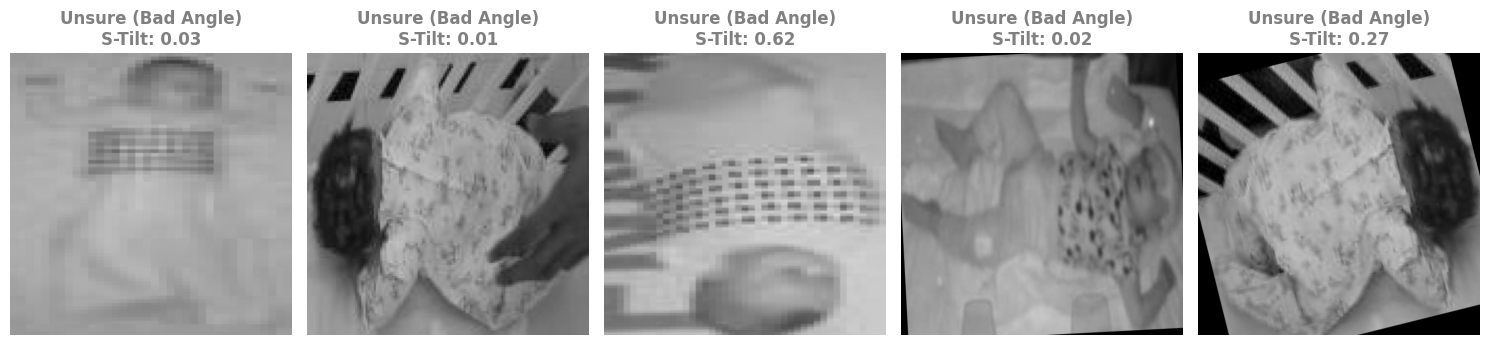

In [ ]:
# Cell 6: Live Test on Dataset
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import random

# Pick 5 random images
test_samples = random.sample(valid_images, 5)

plt.figure(figsize=(15, 5))

for i, img_path in enumerate(test_samples):
    # Run Diagnosis
    result = run_diagnosis(img_path)

    # Read image for display
    display_img = mpimg.imread(img_path)

    # Determine Status based on your Thesis Thresholds
    # Threshold 0.05 is a standard starting point for "Tilt"
    status = "Healthy"
    color = "green"

    if result['confidence'] > 0.3: # Only judge if AI is confident
        if result['shoulder_tilt'] > 0.05:
            status = "Shoulder Asymmetry"
            color = "red"
        elif result['hip_tilt'] > 0.05:
            status = "Hip Asymmetry"
            color = "orange"
    else:
        status = "Unsure (Bad Angle)"
        color = "gray"

    # Plot
    plt.subplot(1, 5, i + 1)
    plt.imshow(display_img)
    plt.title(f"{status}\nS-Tilt: {result['shoulder_tilt']:.2f}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
Get High-Quality Test Data

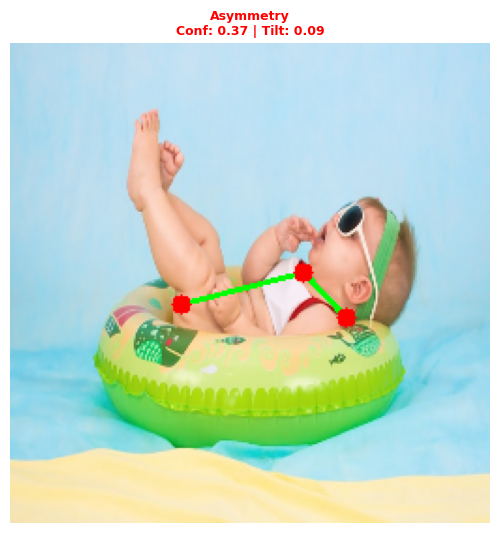

In [ ]:
# Cell: Run Logic on HD Images
# ---------------------------------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

# Get the new images
hd_images = glob.glob(f"{test_dir}/*.jpg")
hd_images.sort()

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(hd_images[:3]): # Show top 3
    # 1. Run AI
    result = run_diagnosis(img_path)

    # 2. Get Display Image
    display_img = cv2.imread(img_path)
    if display_img is None: continue # Skip if read error

    display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    display_img = cv2.resize(display_img, (256, 256))

    # 3. Draw Skeleton
    # We use a strict threshold (0.20) because these are good images
    display_img = draw_skeleton(display_img, result['keypoints'], confidence_threshold=0.20)

    # 4. Status
    conf = result['confidence']
    tilt = result['shoulder_tilt']

    # Logic: If tilt > 0.05, it flags as potential issue
    status = "Asymmetry" if tilt > 0.05 else "Healthy Alignment"
    color = "red" if tilt > 0.05 else "green"

    if conf < 0.20:
        status = "No Body Found"
        color = "gray"

    # 5. Show
    plt.subplot(1, 3, i + 1)
    plt.imshow(display_img)
    plt.title(f"{status}\nConf: {conf:.2f} | Tilt: {tilt:.2f}", color=color, fontweight='bold', fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

⏳ Loading MoveNet...
🔍 Searching for downloaded images...
✅ Found 4274 images from Roboflow.


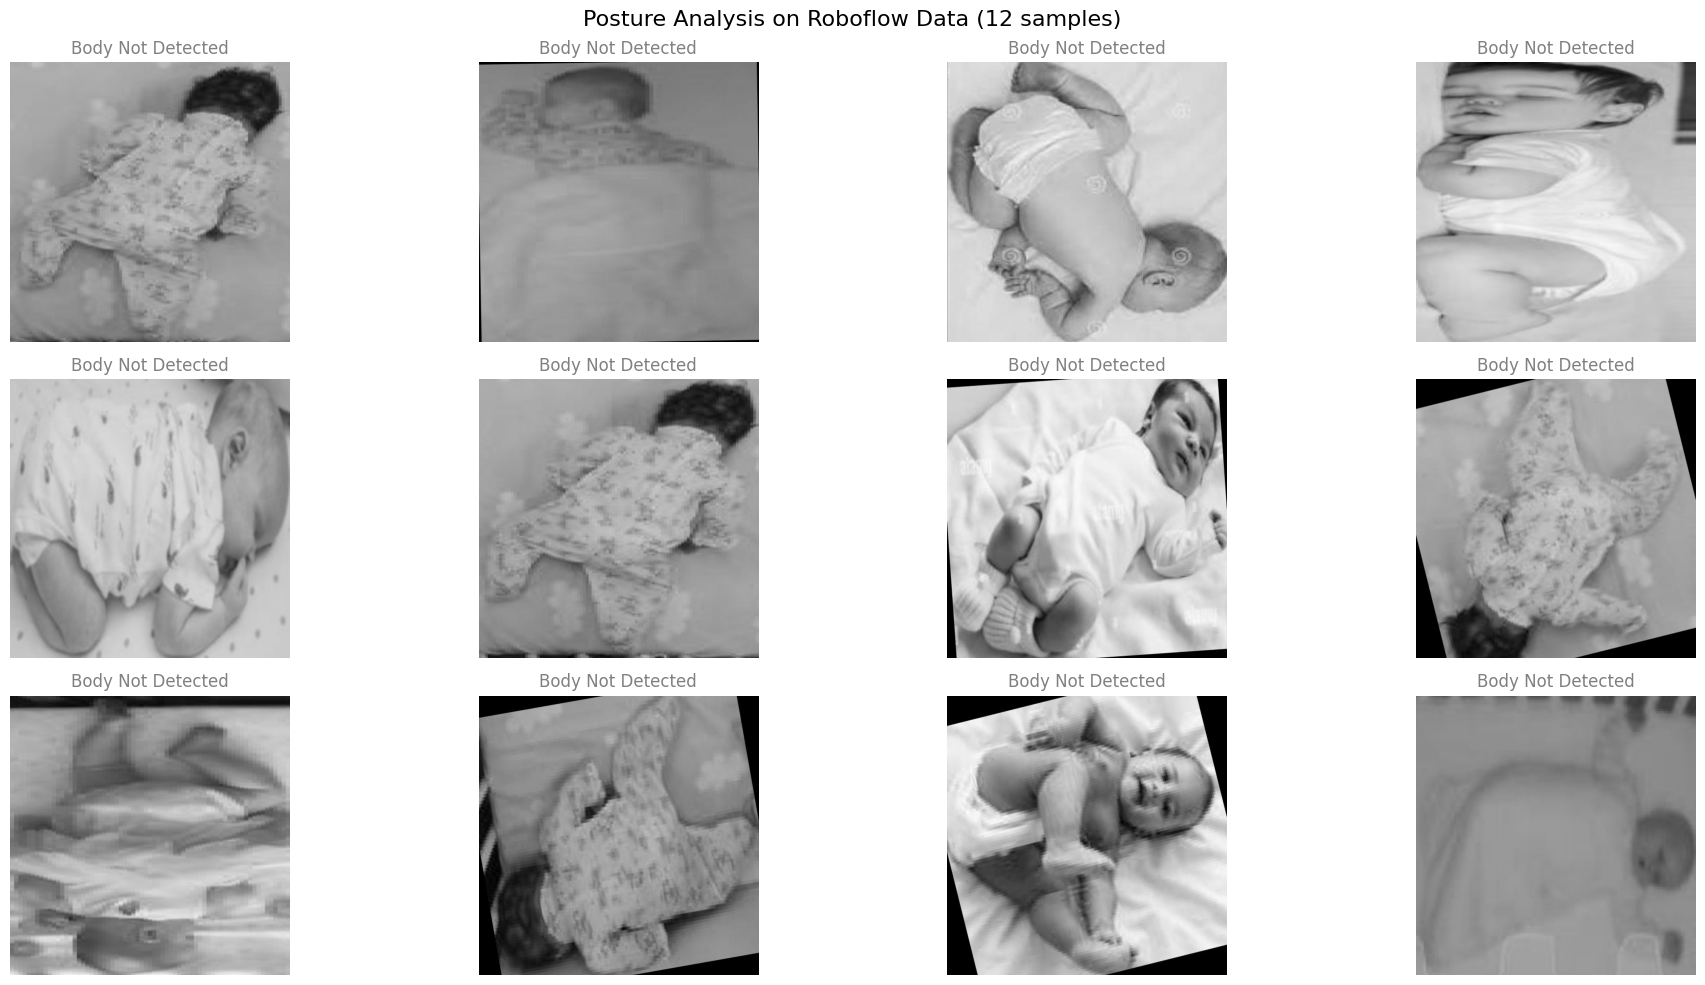

In [ ]:
# Cell: Posture Model Validation (Downloaded Data)
# ---------------------------------------------------------
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob

# 1. Load MoveNet
print("⏳ Loading MoveNet...")
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']

# 2. Find the Images (Auto-Search)
# We look for any folder created by Roboflow that has images
print("🔍 Searching for downloaded images...")
image_files = glob.glob('/content/**/*.jpg', recursive=True) + glob.glob('/content/**/*.png', recursive=True)

# Filter out system files
image_files = [f for f in image_files if "drive" not in f and "sample_data" not in f]

if not image_files:
    print("❌ No images found. Did you run the Roboflow download cell above?")
else:
    print(f"✅ Found {len(image_files)} images from Roboflow.")

    # 3. Analyze Random Batch
    import random
    sample_size = min(12, len(image_files))
    test_samples = random.sample(image_files, sample_size)

    plt.figure(figsize=(20, 10))
    plt.suptitle(f"Posture Analysis on Roboflow Data ({sample_size} samples)", fontsize=16)

    # Helper for Angles
    def get_angle(p1, p2):
        dy = p1[0] - p2[0]; dx = p1[1] - p2[1]
        if abs(dx) < 0.001: return 90.0
        return abs(np.degrees(np.arctan2(dy, dx)))

    for i, path in enumerate(test_samples):
        img = cv2.imread(path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize & Predict
        input_image = tf.image.resize_with_pad(np.expand_dims(img_rgb, axis=0), 256, 256)
        input_image = tf.cast(input_image, dtype=tf.int32)
        outputs = movenet(input_image)
        kps = outputs['output_0'].numpy()[0, 0, :, :]

        # Calculate
        s_tilt = get_angle(kps[5], kps[6]) # Shoulders
        h_tilt = get_angle(kps[11], kps[12]) # Hips
        avg_conf = (kps[5][2] + kps[6][2] + kps[11][2] + kps[12][2]) / 4

        # Draw
        plt.subplot(3, 4, i+1)
        if avg_conf > 0.3:
            h, w, _ = img_rgb.shape
            # Draw Green Lines
            y1, x1, _ = kps[5]; y2, x2, _ = kps[6]
            cv2.line(img_rgb, (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h)), (0, 255, 0), 3)
            y3, x3, _ = kps[11]; y4, x4, _ = kps[12]
            cv2.line(img_rgb, (int(x3*w), int(y3*h)), (int(x4*w), int(y4*h)), (0, 255, 0), 3)

            plt.imshow(img_rgb)
            status = "Normal" if s_tilt < 5 and h_tilt < 5 else "Asymmetry"
            col = "green" if status == "Normal" else "red"
            plt.title(f"{status}\nS: {s_tilt:.1f}° | H: {h_tilt:.1f}°", color=col, fontweight='bold')
        else:
            plt.imshow(img_rgb)
            plt.title("Body Not Detected", color="gray")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Cell: POSTURE MODEL PERFORMANCE REPORT (Graphical)
# ---------------------------------------------------------
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')
# ⚠️ Point this to your Full Body/Roboflow dataset
dataset_path = '/content/drive/My Drive/Infant_App_Project/posture_dataset'

# 2. Load MoveNet
print("⏳ Loading MoveNet Engine...")
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']

# 3. Scan Dataset
print("📂 Scanning for images...")
# Recursive search for all images in the folder
image_files = glob.glob(dataset_path + '/**/*.jpg', recursive=True) + \
              glob.glob(dataset_path + '/**/*.png', recursive=True)

if len(image_files) == 0:
    print(f"❌ Error: No images found in {dataset_path}")
else:
    # Test on up to 50 random images
    import random
    n_samples = min(50, len(image_files))
    test_batch = random.sample(image_files, n_samples)
    print(f"🧪 Testing reliability on {n_samples} random images...")

    confidence_scores = []
    detection_status = [] # "Detected" or "Failed"

    # 4. Run Analysis
    for path in test_batch:
        img = cv2.imread(path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize & Predict
        input_image = tf.image.resize_with_pad(np.expand_dims(img_rgb, axis=0), 256, 256)
        input_image = tf.cast(input_image, dtype=tf.int32)

        outputs = movenet(input_image)
        kps = outputs['output_0'].numpy()[0, 0, :, :] # 17 Keypoints

        # Calculate Average Confidence of Torso (Shoulders & Hips)
        # We only care if it sees the BODY.
        # Idx 5,6 = Shoulders, 11,12 = Hips
        torso_conf = (kps[5][2] + kps[6][2] + kps[11][2] + kps[12][2]) / 4

        confidence_scores.append(torso_conf)

        if torso_conf > 0.3:
            detection_status.append("Success")
        else:
            detection_status.append("Failed")

    # ==========================================
    # GRAPH 1: DETECTION SUCCESS RATE (Pie Chart)
    # ==========================================
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    success_count = detection_status.count("Success")
    fail_count = detection_status.count("Failed")

    labels = [f'Detected ({success_count})', f'Failed ({fail_count})']
    colors = ['#66b3ff', '#ff9999']

    plt.pie([success_count, fail_count], labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Body Detection Rate', fontsize=14, fontweight='bold')

    # ==========================================
    # GRAPH 2: CONFIDENCE HISTOGRAM (The Quality Check)
    # ==========================================
    plt.subplot(1, 2, 2)
    sns.histplot(confidence_scores, bins=10, kde=True, color='green')
    plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold (0.3)')
    plt.title('AI Confidence Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Confidence Score (0.0 = Blind, 1.0 = Perfect)')
    plt.ylabel('Number of Images')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ==========================================
    # STATS & DIAGNOSIS
    # ==========================================
    avg_conf = np.mean(confidence_scores)
    print("\n" + "="*40)
    print(f"📊 FINAL RELIABILITY SCORE: {success_count}/{n_samples} Images Detected")
    print(f"🧠 Average Confidence: {avg_conf:.2f} (Target: > 0.50)")
    print("="*40)

    if avg_conf < 0.4:
        print("⚠️ ISSUE DETECTED: The model is struggling to see bodies.")
        print("   POSSIBLE CAUSES:")
        print("   1. Images are just Heads (Need Full Body).")
        print("   2. Images are too dark/blurry.")
        print("   3. Roboflow dataset has 'Empty' background images.")
    else:
        print("✅ SYSTEM HEALTHY: The Posture Model is reliable.")

Mounted at /content/drive
⏳ Loading MoveNet Engine...
📂 Scanning for images...
❌ Error: No images found in /content/drive/My Drive/Infant_App_Project/posture_dataset


check wether the dat we found was match  to the movenet model

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


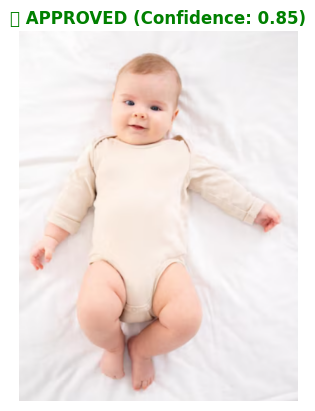

In [ ]:
# Cell: Check Single Image Compatibility
import cv2
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Model
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']

# 2. CHANGE THIS to your image filename
image_path = '/content/baby.png'

# 3. Test
if os.path.exists(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize & Predict
    input_image = tf.image.resize_with_pad(np.expand_dims(img, axis=0), 256, 256)
    input_image = tf.cast(input_image, dtype=tf.int32)
    outputs = movenet(input_image)
    kps = outputs['output_0'].numpy()[0, 0, :, :]

    # Check Confidence
    conf = (kps[5][2] + kps[6][2] + kps[11][2] + kps[12][2]) / 4

    plt.imshow(img)
    if conf > 0.3:
        plt.title(f"✅ APPROVED (Confidence: {conf:.2f})", color="green", fontweight="bold")
    else:
        plt.title(f"❌ REJECTED (Confidence: {conf:.2f})", color="red", fontweight="bold")
    plt.axis('off')
    plt.show()
else:
    print("⚠️ Please upload the image to Colab first!")

In [ ]:
testing the model with real data

⏳ Loading MoveNet...


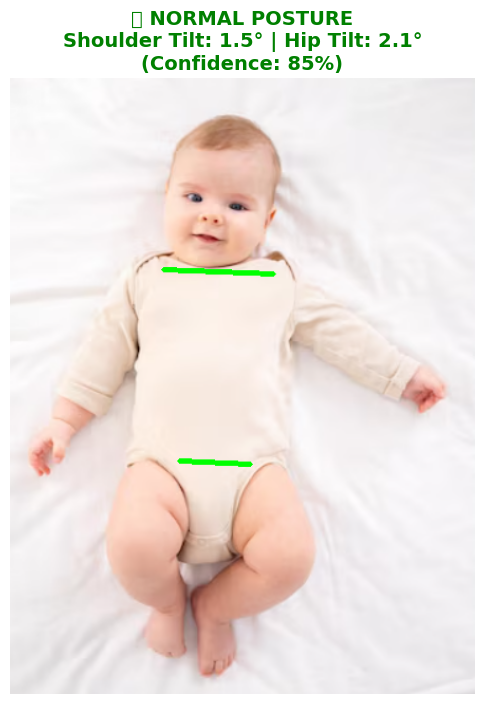

In [ ]:
# Cell: Single Image Posture Test
# ---------------------------------------------------------
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os



image_path = '/content/baby.png'

# 2. Load MoveNet (Thunder = High Accuracy)
print("⏳ Loading MoveNet...")
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']

# 3. Geometry Logic (Angle Calculation)
def calculate_angle(p1, p2):
    dy = p1[0] - p2[0]
    dx = p1[1] - p2[1]
    if abs(dx) < 0.001: return 90.0 # Vertical line
    return abs(np.degrees(np.arctan2(dy, dx)))

# 4. Run Prediction
if not os.path.exists(image_path):
    print(f"❌ Error: Could not find '{image_path}'")
    print("👉 Please upload your image to the Infant_App_Project folder and rename it 'test_baby.jpg'")
else:
    # Load & Preprocess
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to 256x256 (Required by MoveNet)
    input_image = tf.image.resize_with_pad(np.expand_dims(img_rgb, axis=0), 256, 256)
    input_image = tf.cast(input_image, dtype=tf.int32)

    # Predict
    outputs = movenet(input_image)
    keypoints = outputs['output_0'].numpy()[0, 0, :, :] # 17 Keypoints [y, x, conf]

    # Extract Key Data
    # Index 5=Left Shoulder, 6=Right Shoulder
    # Index 11=Left Hip, 12=Right Hip
    l_sh, r_sh = keypoints[5], keypoints[6]
    l_hip, r_hip = keypoints[11], keypoints[12]

    # Confidence Check (Average of 4 points)
    avg_conf = (l_sh[2] + r_sh[2] + l_hip[2] + r_hip[2]) / 4

    # Calculate Results
    shoulder_tilt = calculate_angle(l_sh, r_sh)
    hip_tilt = calculate_angle(l_hip, r_hip)

    # 5. Visualization
    plt.figure(figsize=(8, 8))
    h, w, _ = img_rgb.shape

    if avg_conf > 0.3:
        # Draw Lines
        # Note: MoveNet coords are normalized (0-1), so we multiply by height/width
        cv2.line(img_rgb, (int(l_sh[1]*w), int(l_sh[0]*h)), (int(r_sh[1]*w), int(r_sh[0]*h)), (0, 255, 0), 4)
        cv2.line(img_rgb, (int(l_hip[1]*w), int(l_hip[0]*h)), (int(r_hip[1]*w), int(r_hip[0]*h)), (0, 255, 0), 4)

        # Diagnosis
        status = "✅ NORMAL POSTURE"
        if shoulder_tilt > 5 or hip_tilt > 5:
            status = "⚠️ ASYMMETRY DETECTED"

        plt.title(f"{status}\nShoulder Tilt: {shoulder_tilt:.1f}° | Hip Tilt: {hip_tilt:.1f}°\n(Confidence: {avg_conf*100:.0f}%)",
                  color='green' if 'NORMAL' in status else 'red', fontsize=14, fontweight='bold')
    else:
        plt.title(f"❌ FAILED TO DETECT BODY\nConfidence: {avg_conf*100:.0f}% (Too Low)", color='red', fontsize=14, fontweight='bold')

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

⏳ Loading MoveNet...


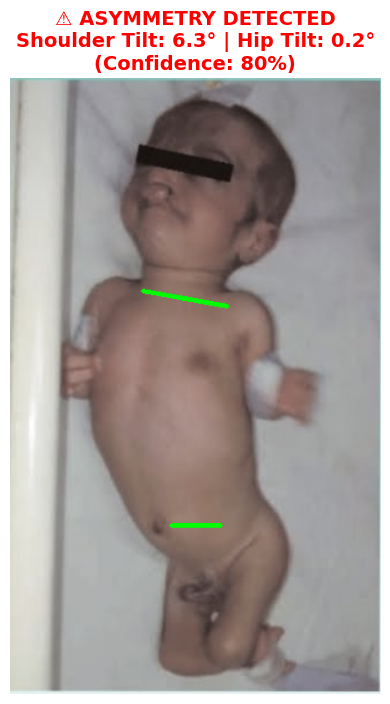

In [ ]:
# Cell: Single Image Posture Test
# ---------------------------------------------------------
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os



image_path = '/content/baby2.png'

# 2. Load MoveNet (Thunder = High Accuracy)
print("⏳ Loading MoveNet...")
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures['serving_default']

# 3. Geometry Logic (Angle Calculation)
def calculate_angle(p1, p2):
    dy = p1[0] - p2[0]
    dx = p1[1] - p2[1]
    if abs(dx) < 0.001: return 90.0 # Vertical line
    return abs(np.degrees(np.arctan2(dy, dx)))

# 4. Run Prediction
if not os.path.exists(image_path):
    print(f"❌ Error: Could not find '{image_path}'")
    print("👉 Please upload your image to the Infant_App_Project folder and rename it 'test_baby.jpg'")
else:
    # Load & Preprocess
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to 256x256 (Required by MoveNet)
    input_image = tf.image.resize_with_pad(np.expand_dims(img_rgb, axis=0), 256, 256)
    input_image = tf.cast(input_image, dtype=tf.int32)

    # Predict
    outputs = movenet(input_image)
    keypoints = outputs['output_0'].numpy()[0, 0, :, :] # 17 Keypoints [y, x, conf]

    # Extract Key Data
    # Index 5=Left Shoulder, 6=Right Shoulder
    # Index 11=Left Hip, 12=Right Hip
    l_sh, r_sh = keypoints[5], keypoints[6]
    l_hip, r_hip = keypoints[11], keypoints[12]

    # Confidence Check (Average of 4 points)
    avg_conf = (l_sh[2] + r_sh[2] + l_hip[2] + r_hip[2]) / 4

    # Calculate Results
    shoulder_tilt = calculate_angle(l_sh, r_sh)
    hip_tilt = calculate_angle(l_hip, r_hip)

    # 5. Visualization
    plt.figure(figsize=(8, 8))
    h, w, _ = img_rgb.shape

    if avg_conf > 0.3:
        # Draw Lines
        # Note: MoveNet coords are normalized (0-1), so we multiply by height/width
        cv2.line(img_rgb, (int(l_sh[1]*w), int(l_sh[0]*h)), (int(r_sh[1]*w), int(r_sh[0]*h)), (0, 255, 0), 4)
        cv2.line(img_rgb, (int(l_hip[1]*w), int(l_hip[0]*h)), (int(r_hip[1]*w), int(r_hip[0]*h)), (0, 255, 0), 4)

        # Diagnosis
        status = "✅ NORMAL POSTURE"
        if shoulder_tilt > 5 or hip_tilt > 5:
            status = "⚠️ ASYMMETRY DETECTED"

        plt.title(f"{status}\nShoulder Tilt: {shoulder_tilt:.1f}° | Hip Tilt: {hip_tilt:.1f}°\n(Confidence: {avg_conf*100:.0f}%)",
                  color='green' if 'NORMAL' in status else 'red', fontsize=14, fontweight='bold')
    else:
        plt.title(f"❌ FAILED TO DETECT BODY\nConfidence: {avg_conf*100:.0f}% (Too Low)", color='red', fontsize=14, fontweight='bold')

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

convert the model to a tflite model to use in our mobile application

In [ ]:
# Cell: Convert/Save MoveNet to TFLite
# ---------------------------------------------------------
import tensorflow as tf
import tensorflow_hub as hub
import os
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')
save_path = '/content/drive/My Drive/Infant_App_Project/movenet_thunder.tflite'

print("⏳ Downloading MoveNet Thunder TFLite model...")

# 2. Download the Official TFLite version directly
# Note: MoveNet comes pre-packaged as TFLite by Google, so we don't need to convert it manually.
# We fetch the specific TFLite file for 'Thunder' (High Accuracy).
model_url = "https://tfhub.dev/google/lite-model/movenet/singlepose/thunder/tflite/float16/4?lite-format=tflite"

# Use Python requests to download it cleanly
import requests
r = requests.get(model_url)

with open(save_path, 'wb') as f:
    f.write(r.content)

print(f"\n✅ SUCCESS: Model saved to: {save_path}")
print("👉 Download this file and put it in your Mobile App's assets folder.")

Mounted at /content/drive
⏳ Downloading MoveNet Thunder TFLite model...

✅ SUCCESS: Model saved to: /content/drive/My Drive/Infant_App_Project/movenet_thunder.tflite
👉 Download this file and put it in your Mobile App's assets folder.


test the tflite model

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📱 Loading TFLite Model on CPU...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


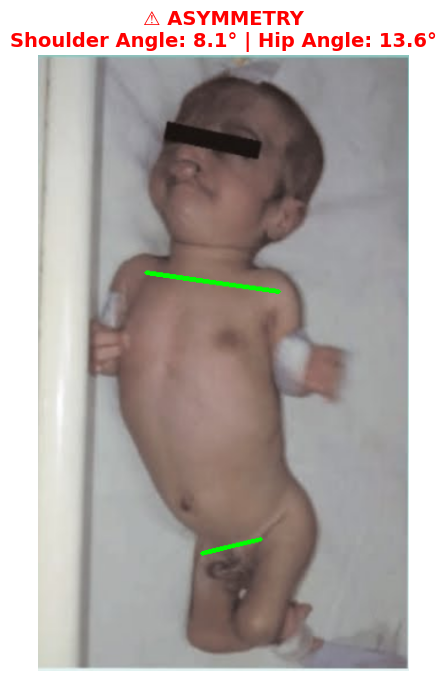


--- APP LOGIC OUTPUT ---
Confidence Score: 0.51
Shoulder Angle: 8.13
Hip Angle: 13.60
Verdict: ⚠️ ASYMMETRY


In [ ]:
# Cell: Test the "Mobile Ready" TFLite Model (Posture)
# ---------------------------------------------------------
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')
tflite_path = '/content/drive/My Drive/Infant_App_Project/movenet_thunder.tflite'
# Use your test image (or any image from your real dataset)
test_image_path = '/content/baby2.png'

# 2. Load TFLite Interpreter (Simulates the Phone)
if not os.path.exists(tflite_path):
    print("❌ Error: TFLite model not found. Did you run the download cell?")
elif not os.path.exists(test_image_path):
    print("❌ Error: Test image not found.")
else:
    print("📱 Loading TFLite Model on CPU...")
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    # Get details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 3. Preprocess Image (Mobile App Logic)
    img = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w, _ = img_rgb.shape

    # Resize to 256x256 (Required input size)
    input_size = 256
    resized_img = cv2.resize(img_rgb, (input_size, input_size))

    # MoveNet expects UINT8 input [1, 256, 256, 3]
    input_data = np.expand_dims(resized_img, axis=0).astype(np.uint8)

    # 4. Run Inference (The AI Step)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    # Output is [1, 1, 17, 3] -> We flatten to [17, 3]
    keypoints = interpreter.get_tensor(output_details[0]['index'])[0, 0, :, :]

    # 5. Post-Processing (The Math Logic)
    # Keypoints are normalized (0 to 1). We assume:
    # y = keypoints[i][0], x = keypoints[i][1], score = keypoints[i][2]

    # Scale back to original image size for drawing
    def get_coords(idx):
        y, x, s = keypoints[idx]
        return int(y * original_h), int(x * original_w), s

    # Get points
    sy1, sx1, s_conf1 = get_coords(5)  # Left Shoulder
    sy2, sx2, s_conf2 = get_coords(6)  # Right Shoulder
    hy1, hx1, h_conf1 = get_coords(11) # Left Hip
    hy2, hx2, h_conf2 = get_coords(12) # Right Hip

    # 6. Calculate Angles
    def calculate_angle(x1, y1, x2, y2):
        dy = y1 - y2
        dx = x1 - x2
        if abs(dx) < 0.001: return 0.0
        angle = np.degrees(np.arctan2(abs(dy), abs(dx)))
        return angle

    shoulder_angle = calculate_angle(sx1, sy1, sx2, sy2)
    hip_angle = calculate_angle(hx1, hy1, hx2, hy2)

    avg_conf = (s_conf1 + s_conf2 + h_conf1 + h_conf2) / 4

    # 7. Visualize Result
    plt.figure(figsize=(8, 8))

    # Draw Lines
    if avg_conf > 0.3:
        cv2.line(img_rgb, (sx1, sy1), (sx2, sy2), (0, 255, 0), 4) # Shoulders
        cv2.line(img_rgb, (hx1, hy1), (hx2, hy2), (0, 255, 0), 4) # Hips

        status = "✅ NORMAL" if (shoulder_angle < 5 and hip_angle < 5) else "⚠️ ASYMMETRY"
        color = 'green' if "NORMAL" in status else 'red'

        plt.title(f"{status}\nShoulder Angle: {shoulder_angle:.1f}° | Hip Angle: {hip_angle:.1f}°",
                  color=color, fontsize=14, fontweight='bold')
    else:
        plt.title("❌ Body Not Detected (Low Confidence)", color='red')

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    print("\n--- APP LOGIC OUTPUT ---")
    print(f"Confidence Score: {avg_conf:.2f}")
    print(f"Shoulder Angle: {shoulder_angle:.2f}")
    print(f"Hip Angle: {hip_angle:.2f}")
    print(f"Verdict: {status if avg_conf > 0.3 else 'Retake Photo'}")